**Integrantes del equipo**


- JAISON AVILA RIVERA
- GABRIEL RESTREPO GIRALDO
- SEBASTIAN GONZALEZ PACHÓN
- MARIA JOSE CAICEDO CORTES


## Carga de datos e importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

from scipy.stats import norm
from scipy import stats

In [28]:
# Descargar los datasets de Drive
!gdown 1NkzavnWM8_WNg1-0LwduLF9mMZ-0H63s > /dev/null 2>&1
!gdown 1CbFRVODHfcyJurFry9dQhQdDojEB9yl_ > /dev/null 2>&1

# Cargar dataset
df1 = pd.read_csv('Journal Personas.csv', sep=',', encoding='latin-1', low_memory=False)
df2 = pd.read_csv('Journal transaccional.csv', sep=',', encoding='latin-1', low_memory=False)

df1_unique = df1.drop_duplicates(subset='ID')
df2.rename(columns={'ID Anónima':'ID'}, inplace=True)

#unir los dos dataset por la columna 'ID'
df = pd.merge(df1_unique, df2, on='ID', how='inner')
df = df[df['ACRM - DEBITO-CREDITO'] != 'R']
df = df[df['ACRM - DEBITO-CREDITO'] != 'E']

#clonar dataframe
data = df.copy()

#borrar columnas con valores vacíos
umbral = 0.8
porcentaje_nulos = data.isnull().mean()
columnas_a_eliminar = porcentaje_nulos[porcentaje_nulos > umbral].index
data = data.drop(columns=columnas_a_eliminar)

# Mostrar resultado
print(f"Tamaño del DataFrame: {data.shape}")

Tamaño del DataFrame: (24610, 145)


In [30]:
data['ACRM - NIVEL DE RIESGO'] = data['ACRM - NIVEL DE RIESGO'].replace({'Medio Bajo': 'Bajo', 'Medio Alto': 'Alto'})

## Variables escogidas: RIESGO ACT ECONÓMICA y NIVEL DE RIESGO


**Justificación:** Se escogen como variables a analizar las variables Nivel de Riesgo (LAFT) y el Nivel de riesgo de la actividad económica dado que el riesgo LAFT se ve influenciado por las ocupaciones de los terceros relacionados a las instituciones. Existen sectores que pueden generar una mayor exposición al lavado de activos tales como las actividades de comercio de metales preciosos, actividades de transporte, inmobiliarias, casinos y juegos de azar, entre otras. Por lo cual, la identificación del nivel de riesgo asociando variables como el riesgo de la actividad económica permite a las entidades realizar de manera anticipada labores de debida diligencia intensificada, así como mejorar los modelos de identificación de operaciones sospechosas

La variable **NIVEL DE RIESGO** se constituye como la variable objetivo. Vamos a analizar primero el nivel de riesgo de que una persona esté realizando actividades financieras ilícitas. Para ello, crearemos inicialmente un diagrama de frecuencia para analizar a fondo las proporciones de las clases que la componen.

<ipython-input-31-09c6f729af6f>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(data=risk_form, x='Nivel de Riesgo', y='Porcentaje', palette=palette)


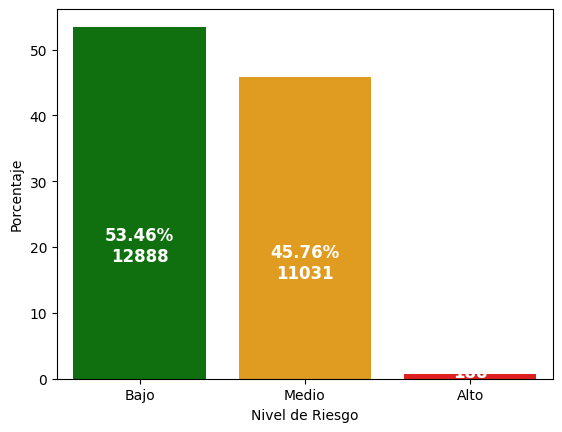

In [31]:
risk_form = data['ACRM - NIVEL DE RIESGO'].value_counts(normalize=True).rename('Proportion').reset_index()
risk_form.rename(columns={risk_form.columns[0]: 'Nivel de Riesgo', 'Proportion': 'Porcentaje'}, inplace=True)
risk_form['Porcentaje'] = np.round(risk_form['Porcentaje'] * 100, decimals=2)

if risk_form['Nivel de Riesgo'].dtype in ['int64', 'float64']:
    risk_form['Nivel de Riesgo'] = risk_form['Nivel de Riesgo'].astype(int)

palette = {'Medio': 'orange', 'Alto': 'red', 'Bajo': 'green'}
bar = sns.barplot(data=risk_form, x='Nivel de Riesgo', y='Porcentaje', palette=palette)

for i in range(risk_form.shape[0]):
    bar.text(
        i, risk_form.loc[i, 'Porcentaje'] / 3,
        f"{risk_form.loc[i, 'Porcentaje']}%\n{data['ACRM - NIVEL DE RIESGO'].value_counts()[risk_form.loc[i, 'Nivel de Riesgo']]}",
        fontdict=dict(color='white', fontsize=12, weight='bold'),
        horizontalalignment='center'
    )


Se puede observar que la distribución de la variable objetivo está claramente desbalanceada, ya que hay muchos más registros con un nivel de riesgo entre bajo y medio que con un nivel de riesgo alto. Esto tiene sentido dentro del contexto, pues en la realidad, no muchas personas están dispuestas a hacer algún tipo de fraude en el ámbito financiero. Sin embargo, este desbalance puede hacer que un posible modelo a partir de estos datos se entrene con un sesgo. Esta poca presencia de datos con un nivel alto de riesgo, resalta la necesidad de un modelo que detecte anomalías.

Por otro lado, la variable **NIVEL DE RIESGO ACTIVIDAD ECONÓMICA** hace referencia la riesgo de la actividad económica que desempeña cada cliente del banco. Analizaremos, de forma similar, la frecuencia de las clases presentes en esta columna a través de gráfico de barras.

<ipython-input-33-676067040baa>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar = sns.barplot(data=risk_form, x='Nivel de Riesgo Act Económica', y='Porcentaje', palette=palette)


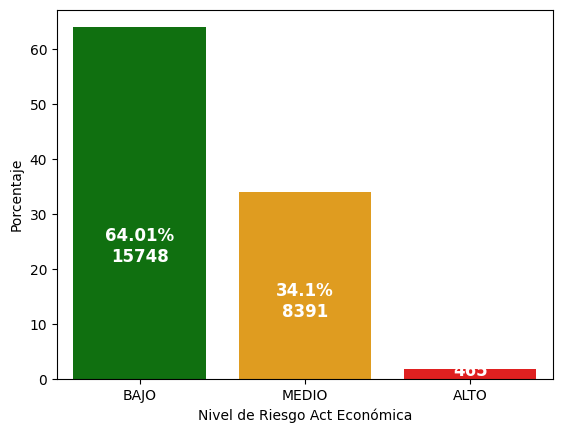

In [33]:
risk_form = data['NIVEL RIESGO ACT ECONOMICA'].value_counts(normalize=True).rename('Proportion').reset_index()
risk_form.rename(columns={risk_form.columns[0]: 'Nivel de Riesgo Act Económica', 'Proportion': 'Porcentaje'}, inplace=True)
risk_form['Porcentaje'] = np.round(risk_form['Porcentaje'] * 100, decimals=2)

if risk_form['Nivel de Riesgo Act Económica'].dtype in ['int64', 'float64']:
    risk_form['Nivel de Riesgo Act Económica'] = risk_form['Nivel de Riesgo Act Económica'].astype(int)

palette = {'MEDIO': 'orange', 'ALTO': 'red', 'BAJO': 'green'}
bar = sns.barplot(data=risk_form, x='Nivel de Riesgo Act Económica', y='Porcentaje', palette=palette)

for i in range(risk_form.shape[0]):
    bar.text(
        i, risk_form.loc[i, 'Porcentaje'] / 3,
        f"{risk_form.loc[i, 'Porcentaje']}%\n{data['NIVEL RIESGO ACT ECONOMICA'].value_counts()[risk_form.loc[i, 'Nivel de Riesgo Act Económica']]}",
        fontdict=dict(color='white', fontsize=12, weight='bold'),
        horizontalalignment='center'
    )


Se puede observar que esta variable presenta una distribución entre sus clases muy similar a la que está presente en la variable de riesgo LAFT. Esto sugiere que estas dos variables están altamente relacionadas, lo cual se intentará corroborar a través de un análisis más detallado. A continuación se hará un gráfico de barras apiladas, que nos proporcionará más información al respecto

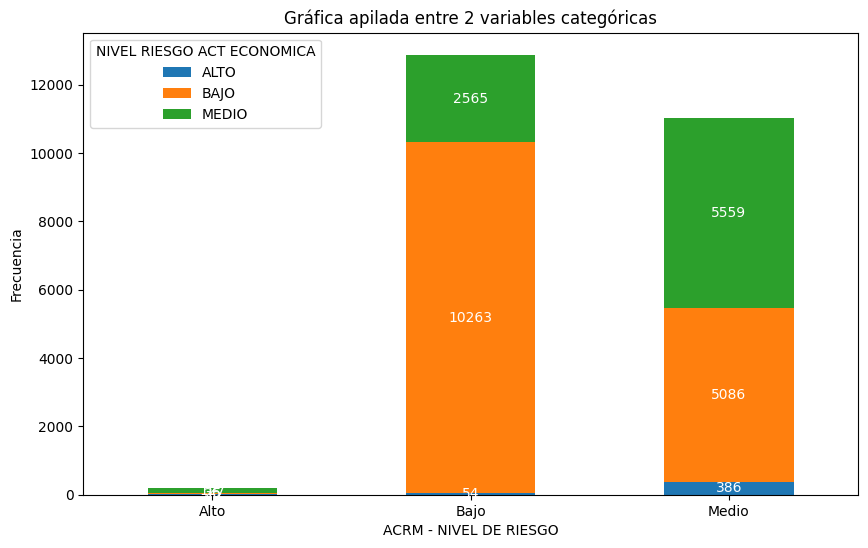

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# Crear la tabla de contingencia
contingencia = pd.crosstab(data['ACRM - NIVEL DE RIESGO'], data['NIVEL RIESGO ACT ECONOMICA'])

# Crear la gráfica
ax = contingencia.plot(kind='bar', stacked=True, figsize=(10,6))

# Agregar etiquetas de valor a cada segmento
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='center', fontsize=10, color='white')

# Personalización de la gráfica
plt.title('Gráfica apilada entre 2 variables categóricas')
plt.xlabel('ACRM - NIVEL DE RIESGO')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.legend(title='NIVEL RIESGO ACT ECONOMICA')
plt.show()


Podemos encontrar una dinámica interesante entre la variable de riesgo de actividad económica y la variable objetivo. La siguiente información puede ser extraída a partir de esta gráfica:

- Dentro del nivel medio de riesgo LAFT se encuentran todos los niveles de actividad económica altos. Esto quiere decir que cuando hay un nivel medio de riesgo LAFT, hay mayor probabilidad de que hay aun nivel alto de riesgo de actividad económica.
- La mayoría de riesgos medios y bajos coinciden entre ambas columnas. El nivel de riesgo de act económica por sí mismo no podría ser un buen indicador de un nivel de riesgo LAFT con respecto a la clase de riesgo ALTO, ya que los niveles altos de act económica se encuentran en el nivel medio de riesgo de la variable objetivo.  

Dada esta información, podemos hacer un análisis estadístico que complemente nuestra fuente de estudio del comportamiento bivariado entre estas dos columnas.

In [42]:
# Tabla de contingencia entre las variables de interés
tabla_contingencia = pd.crosstab(data['ACRM - NIVEL DE RIESGO'], data['NIVEL RIESGO ACT ECONOMICA'])

# Mostrar la tabla
print(tabla_contingencia)


NIVEL RIESGO ACT ECONOMICA  ALTO   BAJO  MEDIO
ACRM - NIVEL DE RIESGO                        
Alto                          25     36    127
Bajo                          54  10263   2565
Medio                        386   5086   5559


In [36]:
# Frecuencias relativas (proporción sobre el total)
tabla_contingencia_prop = pd.crosstab(data['ACRM - NIVEL DE RIESGO'], data['NIVEL RIESGO ACT ECONOMICA'], normalize=True)
print(tabla_contingencia_prop)


NIVEL RIESGO ACT ECONOMICA      ALTO      BAJO     MEDIO
ACRM - NIVEL DE RIESGO                                  
Alto                        0.001037  0.001494  0.005269
Bajo                        0.002241  0.425833  0.106427
Medio                       0.016016  0.211029  0.230654


**Análisis de la Relación Entre Variables basado en la tabla de contingencia**  
  
A partir de las tablas de contingencia entre las frecuencias y las proporciones de estas dos columnas evaluadas, podemos concluir lo siguiente:

- La mayoría de las personas con nivel de riesgo BAJO en actividades económicas también tienen un nivel de riesgo bajo de actividades ilícitas.  
- Los casos de alto riesgo de activiades ilícitas están más distribuidos entre las categorías de actividad económica, pero siguen siendo pocos.  


Con esta nueva información, parece haber una correlación **moderada** entre ambas variables.


Vamos a analizar otro de los indicadores estadísticos. El índice **V de Cramér** se usa para medir la **fuerza de asociación** entre dos variables categóricas (0 = sin relación, 1 = relación fuerte).  

In [37]:
import scipy.stats as stats
import numpy as np

def cramers_v(tabla):
    chi2 = stats.chi2_contingency(tabla)[0]
    n = tabla.sum().sum()  # Total de observaciones
    k = min(tabla.shape) - 1  # Mínimo entre filas y columnas - 1
    return np.sqrt(chi2 / (n * k))

# Calcular V de Cramér
v_cramer = cramers_v(tabla_contingencia)
print(f'V de Cramér: {v_cramer:.4f}')


V de Cramér: 0.2577


**Interpretación:**  
- Contrario a lo que habíamos planteado al inicio, podemos decir que un valor de **0.2577** indica una **asociación moderada** entre ambas variables, por lo que la relación entre estas variables parece no ser tan alta como pensabamos.  
- **No es una relación muy fuerte, pero sí hay cierta dependencia** entre el riesgo de la actividad económica y el nivel de riesgo en ACRM.  


Realizaremos un análisis utilizando otras medidas de asociación que nos darán una pista más certera sobre la existencia de esta relación


In [44]:
from scipy.stats import chi2_contingency

# Crear una tabla de contingencia
tabla_contingencia_prop = pd.crosstab(data['ACRM - NIVEL DE RIESGO'], data['NIVEL RIESGO ACT ECONOMICA'])

# Realizar la prueba de chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_contingencia_prop)

# Imprimir los resultados
print(f"Valor chi-cuadrado: {chi2}")
print(f"P-valor: {p}")
print(f"Grados de libertad: {dof}")

# Interpretar el p-valor
if p < 0.05:
    print("Existe una correlación estadísticamente significativa entre las dos variables.")
else:
    print("No existe una correlación estadísticamente significativa entre las dos variables.")

Valor chi-cuadrado: 3201.3319181961087
P-valor: 0.0
Grados de libertad: 4
Existe una correlación estadísticamente significativa entre las dos variables.


**Medidas de Asociación**  

**Interpretación:**  
- Como el **p-valor es 0.0 (<0.05)**, podemos **rechazar la hipótesis nula**, lo que indica que **existe una relación estadísticamente significativa** entre `ACRM - NIVEL DE RIESGO` y `NIVEL RIESGO ACT ECONOMICA`.  
- A pesar de esto, esta prueba **no mide la fuerza de la relación**, solo indica que existe.


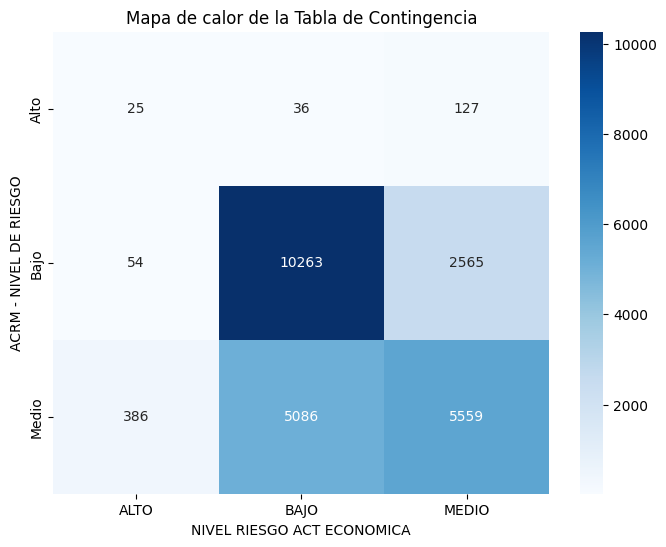

In [40]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(tabla_contingencia, annot=True, fmt='d', cmap='Blues')
plt.title('Mapa de calor de la Tabla de Contingencia')
plt.xlabel('NIVEL RIESGO ACT ECONOMICA')
plt.ylabel('ACRM - NIVEL DE RIESGO')
plt.show()


De acuerdo con el mapa de calor, las clases que más coinciden entre estas variables son "Bajo" y "BAJO". Por otro lado, las que menos coinciden son "Alto" y "ALTO". Es posible que coincidan menos también por el hecho de que están desbalanceados, y además pueden haber otras variables que pueden estar influenciando el nivel de riesgo LAFT y no nos podemos basar exclusivamente en la variable de riesgo de actividad económica.

### **Conclusiones Finales**
1. **Las variables están relacionadas** (confirmado por la prueba de chi-cuadrado con p-valor = 0.0).  
2. **La relación es moderada** (V de Cramér = 0.2577).  
3. **La mayoría de las personas con actividades económicas de bajo riesgo también tienen un bajo riesgo en ACRM.**
4. Dado que la relación entre estas dos variables es moderada, no podemos decir que sea necesario eliminar la variable de actividad económica por redundancia de información, por lo que esta columna permanecerá, pero analizaremos otras variables que, en su conjunto, puedan explicar el comportamiento del nivel de riesgo de actividades ilícitas.
5. **El desbalance de datos** sugiere que un modelo basado en estos datos podría tener problemas para detectar casos de alto riesgo. En este caso nos plantearemos usar técnicas como:
   - Balanceo de clases (SMOTE, submuestreo, ponderación de clases).  
   - Modelos de detección de anomalías.  

**Finalmente:**  
Con este análisis bivariado llegamos a la conclusión de que esta variable explicativa tiene una correlación moderada con la variable objetivo. Por este motivo, debemos explorar más variables además de esta para detectar aquellos datos que son más útiles para llegar a explicar la variable objetivo en un posible modelo.  

Actividades a desarrollar:

- Probar diferentes modelos de clasificación para ver cuál maneja mejor el desbalance.  
- Evaluar a detalle las métricas como, por ejemplo, recall y F1-score para asegurarse de que el modelo no ignore los casos de alto riesgo, ya que esta es el fin último del modelo.  